<a href="https://colab.research.google.com/github/Paulyang5049/tennis-ai-local/blob/main/notebooks/01_train_ball_yolo26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train the YOLO26 tennis-ball detector
Local replay uses pretrained YOLO26 for people/rackets/pose. This notebook fine-tunes a separate ball detector. Default: YOLO26s, 1280 px, 100 epochs, patience 20, batch 4 → 2 → 1 if GPU memory is insufficient. Training and datasets live on Colab's temporary disk; recoverable checkpoints go to Drive.

Public dataset: abdullahtarek/tennis_analysis, Roboflow tennis-ball-detection v6, CC BY 4.0. Keep attribution with derivatives.

## 1. Setup
Select **Runtime → Change runtime type → GPU**. This installs the versioned project wheel from the public GitHub release, including the same model and export code used locally.

In [2]:
from google.colab import files, drive
from pathlib import Path
import subprocess, sys
WHEEL = 'https://github.com/Paulyang5049/tennis-ai-local/releases/download/v0.1.0/tennis_ai_local-0.1.0-py3-none-any.whl'
subprocess.run([sys.executable, '-m', 'pip', 'install', '--ignore-requires-python', WHEEL], check=True)
print('If pip replaced an already imported torch/numpy, restart the session before continuing.')

If pip replaced an already imported torch/numpy, restart the session before continuing.


In [3]:
import torch, importlib.metadata
assert torch.cuda.is_available(), 'Choose a GPU runtime'
print('GPU:', torch.cuda.get_device_name(0))
print({n: importlib.metadata.version(n) for n in ['torch', 'ultralytics', 'numpy']})
drive.mount('/content/drive')
DRIVE = Path('/content/drive/MyDrive/TennisAI')
DRIVE.mkdir(parents=True, exist_ok=True)
print('Checkpoints will be saved to', DRIVE)

GPU: Tesla T4
{'torch': '2.14.0', 'ultralytics': '8.4.140', 'numpy': '2.4.6'}
Mounted at /content/drive
Checkpoints will be saved to /content/drive/MyDrive/TennisAI


## 2. Download and audit
The repository's original 428/100/50 split is **not** blindly reused. Exact decoded-image duplicates are removed and conservative filename families are kept together. Filename families do not prove video identity: inspect `audit.json`, and use separate real phone/broadcast clips for final validation.

{'upstream_commit': 'd557527793820f1e6b06872256824255facd47fd', 'duplicates_removed': [], 'counts': {'train': 468, 'val': 60, 'test': 50}, 'grouping': 'Conservative filename families; source videos remain unverified. Near-duplicates may remain.', 'license': 'CC BY 4.0; retain upstream README attribution'}


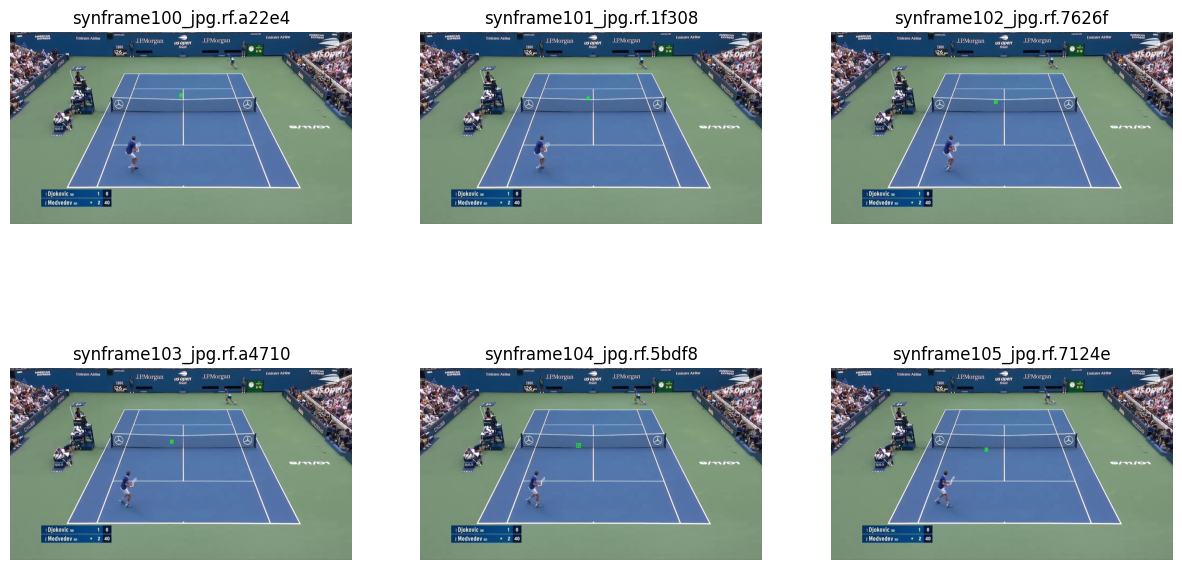

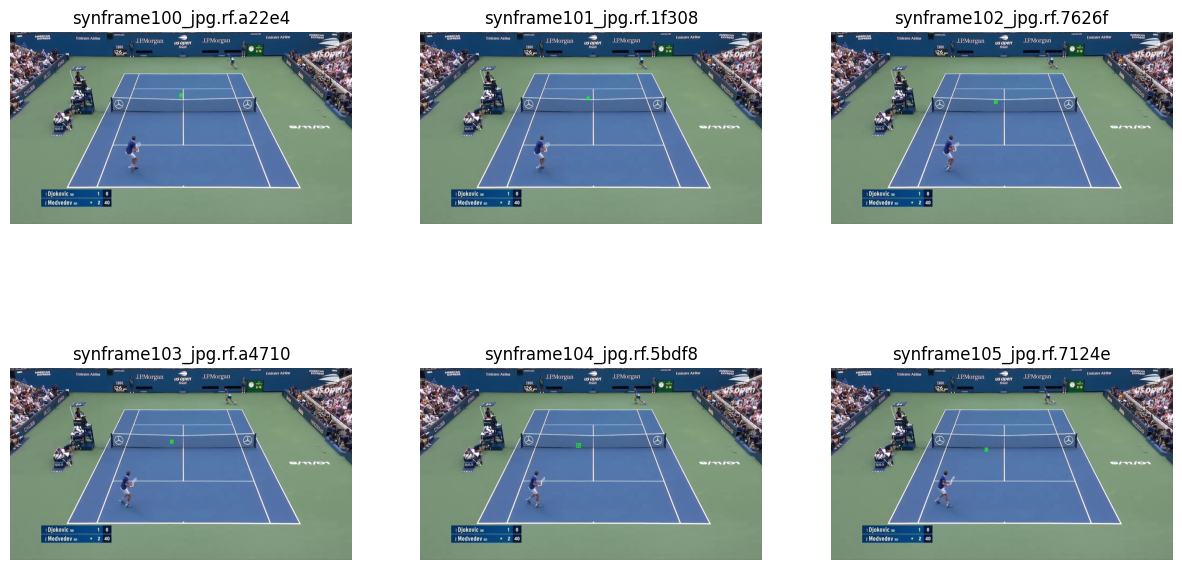

In [4]:
from tennis_ai.training import prepare_ball, label_preview
DATA = Path('/content/tennis-ball')
try:
    data_yaml, audit = prepare_ball(DATA)
    print({k:v for k,v in audit.items() if k != 'manifest'})
except Exception as error:
    raise RuntimeError('Dataset unavailable or audit failed. The local COCO baseline remains usable; fix the data issue before training.') from error
label_preview(DATA)

## 3. Smoke test
Run one short epoch before committing to full training. This does not overwrite the recoverable full-training checkpoint.

In [5]:
from tennis_ai.training import train_ball
train_ball(data_yaml, '/content/ball-runs', DRIVE/'ball', smoke=True)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.14.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tennis-ball/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, for

(PosixPath('/content/ball-runs/smoke'),
 ultralytics.utils.metrics.DetMetrics object with attributes:
 
 ap_class_index: array([0])
 box: ultralytics.utils.metrics.Metric object
 confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e66883bfed0>
 curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
 curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
           0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045

## 4. Train or resume
Set `RESUME=True` after a disconnect to use Drive's last checkpoint. Re-run setup and data preparation in a fresh session first.

In [ ]:
import shutil
RESUME = False
checkpoint = None
if RESUME:
    checkpoint = Path('/content/ball-resume.pt')
    shutil.copy2(DRIVE/'ball'/'last.pt', checkpoint)
run, training_result = train_ball(data_yaml, '/content/ball-runs', DRIVE/'ball', resume=checkpoint)
print('Completed:', run)

Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.14.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tennis-ball/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ball-b4, nbs=64, nms=False, op

## 5. Compare baseline and candidate
Both detectors are evaluated against the same tennis-ball labels, with the baseline's COCO sports-ball class mapped correctly. Validation selects a candidate; test results are reported separately. Image recall is not trajectory coverage.

In [ ]:
import json
from tennis_ai.training import evaluate_ball_images
best = DRIVE/'ball'/'best.pt'
report = {}
for split in ['val', 'test']:
    report[split] = {
        'baseline': evaluate_ball_images('yolo26s.pt', DATA, split, baseline=True),
        'candidate': evaluate_ball_images(best, DATA, split),
    }
a, b = report['val']['baseline'], report['val']['candidate']
report['image_candidate_pass'] = b['recall'] > a['recall'] and b['fp'] <= a['fp']
report['promotion'] = 'Candidate only: validate held-out video coverage and false detections before selecting locally.'
(DRIVE/'ball'/'evaluation.json').write_text(json.dumps(report, indent=2))
print(json.dumps(report, indent=2))

## 6. Export to the Mac
Download and unzip this bundle inside the local project's `models/` folder. In the app, enter its folder in **Custom Colab model bundles**, verify it, then analyze the same held-out clips with baseline and candidate. Keep the baseline unless observed ball coverage improves without more false detections.

In [ ]:
from tennis_ai.artifacts import package
bundle = package(best, DRIVE/'ball-bundle', 'ball', 1280, report)
archive = shutil.make_archive('/content/ball-bundle', 'zip', bundle)
files.download(archive)